<a href="https://colab.research.google.com/github/Yeshasvin/Fitness_exercise_tracker/blob/main/SOULPAGE_SOL_ASSNMT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!nvidia-smi

Thu Dec 26 04:59:10 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   42C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

License Plate Detection and Recognition Work Flow

  Step 1: Data Exploration

  Step 2 : License Plate Detection
  
  Step 3: License Plate Character Recognition

# Data Exploration

# License Plate Detetion

In [3]:
import os
os.environ['WANDB_MODE'] = 'disabled'



In [4]:
# Cloning YOLO v10 model from git hub for License Plate detection
!git clone https://github.com/THU-MIG/yolov10.git

Cloning into 'yolov10'...
remote: Enumerating objects: 20332, done.
remote: Total 20332 (delta 0), reused 0 (delta 0), pack-reused 20332 (from 1)
Receiving objects: 100% (20332/20332), 11.09 MiB | 13.46 MiB/s, done.
Resolving deltas: 100% (14352/14352), done.


In [5]:
%cd yolov10

/content/yolov10


In [6]:
!pwd

/content/yolov10


In [7]:
# Installing required packages to train and detect License Plates using a YOLO v10 model
!pip install .

Processing /content/yolov10
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.1.34-py3-none-any.whl size=731421 sha256=0af404af8d15128a1f0fcc55693ac2a92bbe29dc01dc7e1cf5fc64eefde49099
  Stored in directory: /tmp/pip-ephem-wheel-cache-ezyi6oyw/wheels/51/93/e8/22d2e815ced343915c15d86b2a00d95eb0a997d012527fbea7
Successfully built ultralytics


In [8]:
# Installing Required Pretrained YOLO v10 models
import os
import urllib.request

# Create a directory for the weights in the current working directory
weights_dir = os.path.join(os.getcwd(), "weights")
os.makedirs(weights_dir, exist_ok=True)

# URLs of the weight files
urls = [
    "https://github.com/jameslahm/yolov10/releases/download/v1.0/yolov10n.pt",
    "https://github.com/jameslahm/yolov10/releases/download/v1.0/yolov10s.pt",
    "https://github.com/jameslahm/yolov10/releases/download/v1.0/yolov10m.pt",
    "https://github.com/jameslahm/yolov10/releases/download/v1.0/yolov10b.pt",
    "https://github.com/jameslahm/yolov10/releases/download/v1.0/yolov10x.pt",
]

# Download each file
for url in urls:
    file_name = os.path.join(weights_dir, os.path.basename(url))
    urllib.request.urlretrieve(url, file_name)
    print(f"Downloaded {file_name}")

Downloaded /content/yolov10/weights/yolov10n.pt
Downloaded /content/yolov10/weights/yolov10s.pt
Downloaded /content/yolov10/weights/yolov10m.pt
Downloaded /content/yolov10/weights/yolov10b.pt
Downloaded /content/yolov10/weights/yolov10x.pt


In [9]:
! unzip SoulPageIT_assignment.zip

Archive:  SoulPageIT_assignment.zip
   creating: SoulPageIT_assignment/
   creating: SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/
  inflating: SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/License Plate Recognition.docx  
   creating: SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/Licplatesdetection_train/
   creating: SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/Licplatesdetection_train/license_plates_detection_train/
  inflating: SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/Licplatesdetection_train/license_plates_detection_train.cache  
  inflating: SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/Licplatesdetection_train.csv  
   creating: SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/Licplatesrecognition_train_1/
   creating: SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/Licplatesrecognition_train_1/license_plates_recognition_train/
  inflating: SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/Licplatesrecognition_train_1/license_plates_recognition_train/0.jpg  
  in

In [11]:
# Training a YOLO v10 model on the given Training images for License Plate Detection
!yolo task=detect mode=train epochs=50 batch=16 plots=True model=weights/yolov10n.pt data=dataset.yaml

/usr/local/lib/python3.10/dist-packages/ultralytics/nn/tasks.py:733: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cpu")
New https://py

In [16]:
! yolo task=detect mode=predict conf=0.25 save=True model=/content/yolov10/runs/detect/train/weights/best.pt source=/content/yolov10/SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/test/test/test/1002.jpg

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
  File "/usr/local/lib/python3.10/dist-packages/ultralytics/cfg/__init__.py", line 514, in entrypoint
    check_dict_alignment(full_args_dict, {a: ""})
  File "/usr/local/lib/python3.10/dist-packages/ultralytics/cfg/__init__.py", line 324, in check_dict_alignment
    raise SyntaxError(string + CLI_HELP_MSG) from e
SyntaxError: 'SCIENTIST_ASSIGNMENT/test/test/test/1002.jpg' is not a valid YOLO argument. 

    Arguments received: ['yolo', 'task=detect', 'mode=predict', 'conf=0.25', 'save=True', 'model=/content/yolov10/runs/detect/train/weights/best.pt', 'source=/content/yolov10/SoulPageIT_assignment/DATA', 'SCIENTIST_ASSIGNMENT/test/test/test/1002.jpg']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of {'segment', 'pose', 'obb', 'classify', 'detect'}
                MODE (required) is one of {'benchmar

## Model Testing

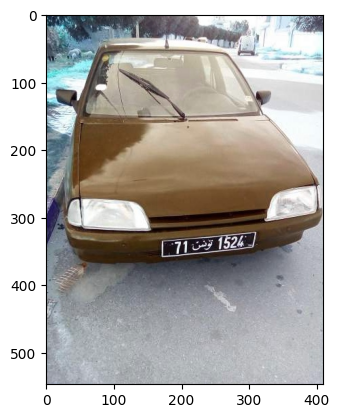

In [12]:
import cv2
import matplotlib.pyplot as plt
img = cv2.imread('/content/yolov10/SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/test/test/test/1002.jpg')
plt.imshow(img)


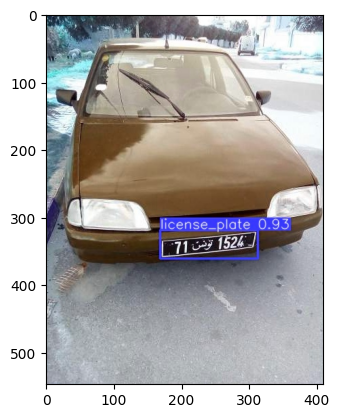

In [15]:
img = cv2.imread('/content/yolov10/runs/detect/predict/1002.jpg')
plt.imshow(img)

## Batch Prediction for Test Images

In [18]:
! yolo task=detect mode=predict conf=0.25 save=True model=/content/yolov10/runs/detect/train/weights/best.pt source="/content/yolov10/SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/test/test/test"

/usr/local/lib/python3.10/dist-packages/ultralytics/nn/tasks.py:733: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cpu")
Ultralytics YO

In [38]:
from  ultralytics import YOLOv10
model = YOLOv10('/content/yolov10/runs/detect/train/weights/best.pt')
images_path = "/content/yolov10/SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/test/test/test"

results = model(images_path, save=True)

/content/yolov10/ultralytics/nn/tasks.py:733: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cpu")


image 1/210 /content/yolov10/SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/test/test/test/1000.jpg: 448x640 1 license_plate, 11.5ms
image 2/210 /content/yolov10/SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/test/test/test/1001.jpg: 640x384 1 license_plate, 48.2ms
image 3/210 /content/yolov10/SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/test/test/test/1002.jpg: 640x480 1 license_plate, 47.9ms
image 4/210 /content/yolov10/SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/test/test/test/1003.jpg: 384x640 1 license_plate, 40.6ms
image 5/210 /content/yolov10/SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/test/test/test/1004.jpg: 640x384 1 license_plate, 11.1ms
image 6/210 /content/yolov10/SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/test/test/test/1005.jpg: 640x384 1 license_plate, 9.8ms
image 7/210 /content/yolov10/SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/test/test/test/1006.jpg: 640x480 1 license_plate, 9.6ms
image 8/210 /content/yolov10/SoulPageIT_assignment/DATA SCIENTIS

In [46]:
if len(results) > 0:
    for result in results:
        # Checking if there are any detections in the current result
        if len(result.boxes) > 0:
            print(f"Predicted Coordinates: {result.boxes.xywh}")  # Bounding box coordinates
            print(f"Image Path: {result.path}")  # Path to the image
            print(f"Image Path: {result.path}")
        else:
            print(f"No detections for image: {result.path}")
else:
    print("No results found.")

Predicted Coordinates: tensor([[371.4601, 248.2328, 235.1878,  53.6597]], device='cuda:0')
Image Path: /content/yolov10/SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/test/test/test/1000.jpg
Image Path: /content/yolov10/SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/test/test/test/1000.jpg
Predicted Coordinates: tensor([[150.6628, 320.2896, 131.2318,  33.5404]], device='cuda:0')
Image Path: /content/yolov10/SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/test/test/test/1001.jpg
Image Path: /content/yolov10/SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/test/test/test/1001.jpg
Predicted Coordinates: tensor([[240.3338, 340.5326, 143.7735,  42.3552]], device='cuda:0')
Image Path: /content/yolov10/SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/test/test/test/1002.jpg
Image Path: /content/yolov10/SoulPageIT_assignment/DATA SCIENTIST_ASSIGNMENT/test/test/test/1002.jpg
Predicted Coordinates: tensor([[293.8668, 188.8262,  79.9173,  24.0768]], device='cuda:0')
Image Path: /content/yolov10/S

# License Plate Character Recognition

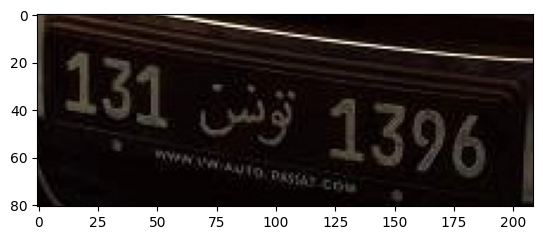

In [48]:
# Cropping the license Plates from detected images

for i, result in enumerate(results):
  for box in result.boxes.xyxy: # Extracting the bounding boxes
    x1, y1, x2, y2 = map(int, box.tolist())

    image = cv2.imread(result.path)
    cropped_plate = image[y1:y2, x1:x2]
    plt.imshow(cropped_plate)
    cv2.imwrite(f"cropped_plate_{i}.jpg", cropped_plate) # saving the cropped Plates


## Intalling Pretrained OCR model for License Plate Character Recognition

In [56]:
# !pip install pytesseract
# !sudo apt-get install tesseract-ocr

!pip install pytesseract
!apt install tesseract-ocr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.


In [58]:
import pytesseract
from pytesseract import Output

sample_plate = cv2.imread('/content/yolov10/cropped_plate_1.jpg')
gray_plate = cv2.cvtColor(sample_plate, cv2.COLOR_BGR2GRAY)
text = pytesseract.image_to_string(gray_plate, config='--psm 7')
print(text)

## Building a Custom OCR Model

'\x0c'